We all sometimes wish the world looked a bit different, fortunately statistics has the answer! I'm going to detail some useful statistical tools to draw conclusions about data from a different distribution than your empirical data generating distribution. This allows us to answer *what if* questions and reason about counterfactual outcomes.

### Importance sampling

Imagine we want to find an expectation involving some r.v. $X \sim P$ but we don't know how to sample from $P$ (or similarly, we don't have data). If we know the pdf $p(x)$ there is a neat trick to calculate it using samples from another distribution $Q$.

$$\mathbb{E}_P[f(X)] = \int f(x) dP = \int f(x) p(x) dx = \int f(x) \frac{p(x)}{q(x)} q(x) dx = \int f(x) \frac{p(x)}{q(x)} dQ = \mathbb{E}_Q[f(Z)\frac{p(Z)}{q(Z)}].$$

In other words, to calculate $\mathbb{E}[f(X)]$ where $X \sim P$, draw $N$ samples $z_i$ from another distribution $Q$ and calculate $\mathbb{E}[f(Z)\frac{p(Z)}{q(Z)}]\approx \frac{1}{N}\sum_i f(z_i) \frac{p(z_i)}{q(z_i)}$.

A variant of this, self-normalized importance sampling, also works if you only know $p(x) = c p_0(x)$ up to a normalizing constant, useful for Bayesian posteriors.

> The density ratio $\frac{p}{q}$ is also known as the Radon-Nikodym derivative of the measure $P$ w.r.t. $Q$, we can see this family of techniques as a change of measure. If you're not familiar with the notation $dP$, we can formally let $dP=\frac{dP}{dx}dx=p(x)dx$. The pdf $p$ is the Radon-Nikodym derivative of the measure/cdf $P$ w.r.t. the Lebesgue measure on the real line, the measure of uniform distributions. On $\mathbb{R}$ the Radon-Nikodym derivative $\frac{p}{q}$ exists if the support of $Q$ covers the support of $P$. In practice you would need a relatively slowly decreasing $q$ such that $\frac{p}{q} \in L^1$.

If $X \sim \mathcal{N}(0,1)$ find $P(X>10)$. Sampling from the standard normal is of course easy, but we would quickly notice that we would record vanishingly few samples above 10. So instead we sample from a shifted exponential $Z \sim \text{Exp}(1)$ with importance sampling.

$$P(X>10) = \mathbb{E}_\mathcal{N}[\mathbb{1}_{X>10}] = \mathbb{E}_{\text{Exp}}[\frac{e^{-\frac{(Z+10)^2}{2}}}{\sqrt{2 \pi} e^{-Z}}] = \mathbb{E}_{\text{Exp}}[\frac{e^{Z-\frac{(Z+10)^2}{2}}}{\sqrt{2 \pi}}].$$

In [30]:
import numpy as np
np.random.seed(123)
import scipy as sp
N= 1_000_000
mu_f = sp.stats.norm.sf(10)
z = np.random.exponential(1,N)
f = np.exp(z - 0.5 * (z+10)**2 - 0.5 * np.log(2 * np.pi))
assert np.abs(np.mean(f)/mu_f -1)<0.05
print(f"mean: {np.mean(f):.2e}, std: {np.std(f):.2e}")

mean: 7.60e-24, std: 1.58e-23


Variance is quite high for this estimator, but if the alternative is to draw >> $10^{24}$ samples...

> Fun fact, people say the silver crash of Feb 2026 was a $10\sigma$-event. Very unfortunate.

### Inverse Probability Weighting




A particularly useful application is when your target distribution is uniform. If you have confounded data on interventions $T$, outcomes $Y$, and features/covariates $X$ you may ask the question *what would this data have looked like if we had done an A/B test*?

In this case you would imagine a world where treatments are randomized everywhere. Your data generating distribution can be factored as 
$$q(Y,T,X)=q(Y|T,X)q(T|X)q(X)$$
In an A/B setting your target treatment policy $q(T|X)$ would be a uniform distribution $p(T|X) \propto 1$. In our importance sampling formula we can simply set the numerator to a constant.

IPW can be applied to general machine learning algorithms by weighting each datapoint by $\frac{1}{q(T=\text{observed}|X)}$, using some classifier as treatment propensity model. This model would now approximate learning from an imagined unconfounded dataset, under standard assumptions.

### Control Variates

Not directly related to the premise but another useful technique, to decrease the variance of an estimator.

If we want to estimate $\mathbb{E}[f(X)]$ and have another correlated r.v. $h(X)$ available with known mean $\mu_h = \mathbb{E}[h(X)]$, we can construct an unbiased estimator as $$\mathbb{E}[\tilde{f}(X)] =  \mathbb{E}[f(X) + \theta (h(X) - \mu_h)].$$ This estimator has variance  $$\mathbb{V}[\tilde{f}(X)]=\mathbb{V}[{f}(X)] + \theta^2\mathbb{V}[{h}(X)] + 2\theta \text{Cov}({f}(X), {h}(X)).$$

With minimal variance at $\theta^* = -\frac{\text{Cov}({f}(X), {h}(X))}{\mathbb{V}[{h}(X)]}.$

The maximal variance reduction is $\frac{\mathbb{V}[{\tilde{f}}(X)]}{\mathbb{V}[{f}(X)]} = 1- \rho^2(f,h).$

Let's get back to $P(X>10)$ and try to decrease the variance. I think a good control variate would be $h = \log(Z)$, with mean $\mathbb{E}[\log(Z)] = -\gamma$ [The Euler-Mascheroni constant](https://en.wikipedia.org/wiki/Euler%27s_constant#Integrals).

In [31]:
from statsmodels.regression.linear_model import OLS
h = np.log(z)
# Estimate optimal theta
theta = -OLS(f,h).fit().params[0]
mu_h = -np.euler_gamma
f_cv = f + theta * (h-mu_h)
assert np.abs(np.mean(f_cv)/mu_f-1)<0.05
print(f"mean: {np.mean(f_cv):.2e}, std: {np.std(f_cv):.2e}")

mean: 7.61e-24, std: 7.90e-24


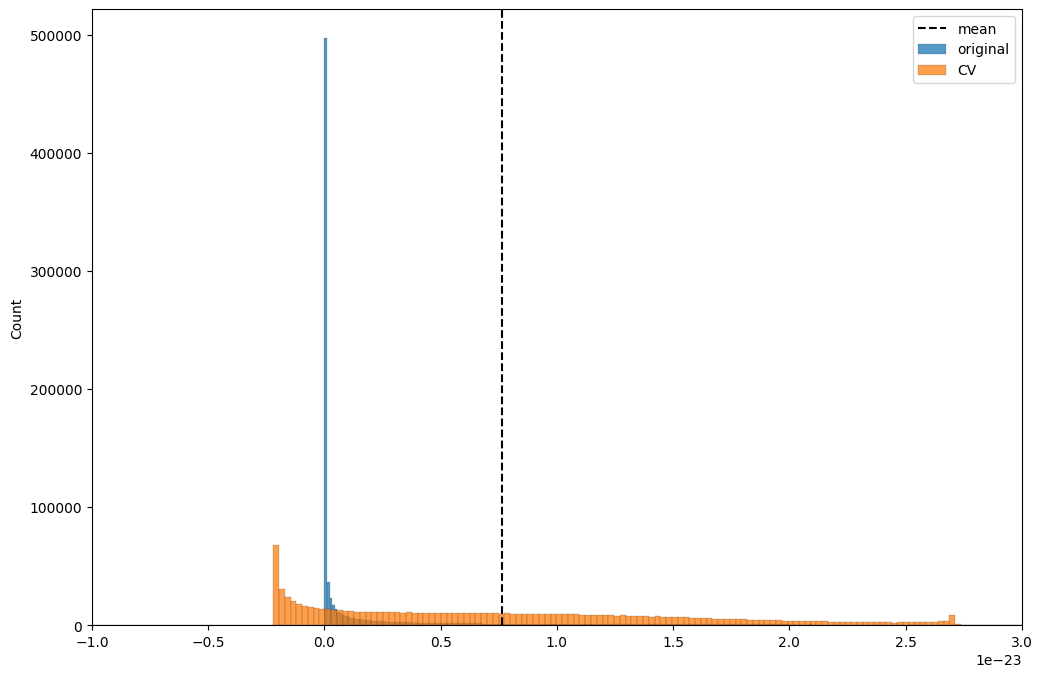

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc("figure", figsize= (12,8))
sns.histplot(f, label="original")
sns.histplot(f_cv, label="CV")
plt.axvline(mu_f, label="mean", color="black", linestyle="dashed")
plt.xlim([-1e-23, 3e-23])
plt.legend();

A common variant of this is CUPED where $h$ is the target $Y$ measured for each unit before the data period. In this case the mean $\mathbb{E}[h]$ is unknown, but will cancel out for estimates of differences like ATE, CATE.

### Doubly Robust Estimators

Like CUPED these are relevant to causal estimands, for example the Conditional Average Treatment Effect $\mathbb{E}[Y^1 - Y^0 | X]$. We could of course build separate models for the counterfactual treatment cases, or include the treatment as a feature, but do you trust a general purpose machine learning algorithm to put special attention to the one thing you're interested in, the treatment effect?

We can introduce a control variate in the IPW estimator for the CATE as $\mathbb E[\frac{1}{P(T=t_i | X)}Y|X] = \mathbb E[\frac{1}{P(T=t_i | X)}Y - (\frac{\mathbf{1}_{T=t_i}}{P(T=t_i | X)}-1)\widetilde{Y}|X]$ where $\widetilde{Y}$ is some informed guess, an outcome model. In practice this is a 3 stage process: estimate a propensity model $e(x) = P(T=t_i | X)$, an outcome model $\mu(X) = \mathbb E[Y | X]$, construct an unbiased estimator of the ATE/CATE by fitting a regression model to the pseudo-labels above.

The double robustness alluded to is because this estimator is unbiased if we know the true propensity *or* outcome model. If we don't, the error scales as the product of these model errors, which is often a good thing. No first order errors in nuisance model specification is also called Neyman Robustness.

### Off-policy Evaluation

The same principles apply whether you model or critique. If you're interested in a hypothetical scenario that's different from your DGP, you should let the evaluation metric reflect that, for example applying IPW to the test set.

### Bonus: Instrumental Variables 
Since I started deriving estimators from causal inference in hand-wavy, eclectic ways avoiding standard notation, here's another one.

We're interested in the ATE of treatment $T$ on the outcome $Y$ under confounding. If we can't measure confounders, IPW and DR are off the table. Another approach that rests on very different assumptions is IV. If we have another r.v. $Z$ that acts on the treatment, has no direct effect on the outcome except through its action on the treatment and is not confounded with treatment or outcome, we can estimate the ATE without controlling for confounders at all. 

$$\frac{dY}{\partial z} = \frac{\partial Y}{\partial t} \frac{\partial t}{\partial z} + \frac{\partial Y}{\partial z}$$
$$\frac{\partial Y}{\partial z} = 0 \implies \frac{\partial Y}{\partial t} = \frac{\frac{d Y}{\partial z}}{\frac{\partial t}{\partial z}}$$

The numerator can be estimated using a linear regression of $Y$ on $Z$ (there is no direct effect by assumption, the regression coefficient measures the total derivative through $T$), the denominator by a regression of $T$ on $Z$ (the direct effect).


This post has glossed over *many* important caveats and is really just a reflection of my own learning journey. If this piques your interest or you're wondering why all the fuss about counterfactual estimation, I recommend [Causal Inference: What If](https://miguelhernan.org/whatifbook) and [Statistical Rethinking](https://xcelab.net/rm/).
